In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping # Added for early stopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

IMAGE_SIZE = 224

BATCH_SIZE = 64

NUM_CLASSES = 7

EPOCHS = 65

LEARNING_RATE = 0.001

PATIENCE = 10 # Added for EarlyStopping callback

# Keras/TensorFlow automatically handles GPU if available
print("TensorFlow using GPU:", tf.test.is_gpu_available())

TensorFlow using GPU: True


In [ ]:
# ============================================================
# 3. LOAD FER2013 DATASET
# ============================================================

df = pd.read_csv('fer2013.csv')

print("\nDataset loaded successfully!")

print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())


Dataset loaded successfully!
Dataset shape:
(35887, 3)

First 5 rows:
   emotion     Usage                                             pixels
0        0  Training  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  Training  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  Training  231 212 156 164 174 138 161 173 182 200 106 38...
3        4  Training  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        6  Training  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [ ]:
# ============================================================
# 4. CHECK DATASET
# ============================================================

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nEmotion distribution:")
print(
    df["emotion"].value_counts().sort_index()
)

print("\nDataset usage:")
print(
    df[" Usage"].value_counts()
)


# Remove missing rows
df = df.dropna().reset_index(drop=True)

print("\nDataset shape after cleaning:")
print(df.shape)


Column names:
['emotion', ' Usage', ' pixels']

Missing values:
emotion    0
 Usage     0
 pixels    0
dtype: int64

Emotion distribution:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64

Dataset usage:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

Dataset shape after cleaning:
(35887, 3)


### Filter out malformed pixel strings

Based on the error, some pixel strings might not contain the correct number of values for a 48x48 image. This step ensures that only correctly formatted images are used.

In [ ]:
# Assuming IMAGE_SIZE is 48 (original FER2013 image size), but the model expects 224x224.
# The raw pixel data is 48x48.
RAW_IMAGE_SIZE = 48
EXPECTED_PIXELS = RAW_IMAGE_SIZE * RAW_IMAGE_SIZE

# Create a boolean mask for rows with valid pixel string length
# We check if the number of space-separated values equals EXPECTED_PIXELS
valid_pixel_mask = df[' pixels'].apply(lambda x: len(x.split()) == EXPECTED_PIXELS)

# Filter the DataFrame to keep only valid rows
df_cleaned = df[valid_pixel_mask].copy()

# Print information about dropped rows (if any)
num_dropped_rows = len(df) - len(df_cleaned)
if num_dropped_rows > 0:
    print(f"Dropped {num_dropped_rows} rows with malformed pixel strings.")
    print(f"Original shape: {df.shape}, Cleaned shape: {df_cleaned.shape}")
else:
    print("No malformed pixel strings found, no rows dropped.")

# Update the global df to the cleaned version
df = df_cleaned

print("\nUpdated Dataset shape after pixel string cleaning:")
print(df.shape)

No malformed pixel strings found, no rows dropped.

Updated Dataset shape after pixel string cleaning:
(35887, 3)


In [ ]:
# ============================================================
# 5. CONVERT PIXELS TO IMAGE
# ============================================================

def pixels_to_image(pixel_string):

    # Convert pixel string to numerical array
    pixels = np.array(
        pixel_string.split(),
        dtype=np.uint8
    )

    # FER2013 images are 48 x 48
    image = pixels.reshape(48, 48)

    return image

In [ ]:
# ============================================================
# 6. CONVERT GRAYSCALE TO RGB
# ============================================================

def prepare_image(pixel_string):

    # Convert pixels into 48 x 48 grayscale image
    image = pixels_to_image(
        pixel_string
    )

    # Convert grayscale to 3-channel RGB
    image = cv2.cvtColor(
        image,
        cv2.COLOR_GRAY2RGB
    )

    return image

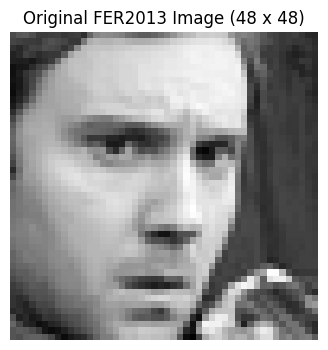

In [ ]:
# ============================================================
# 7. DISPLAY ORIGINAL IMAGE
# ============================================================

sample_image = pixels_to_image(
    df.iloc[0][" pixels"]
)

plt.figure(figsize=(4, 4))

plt.imshow(
    sample_image,
    cmap="gray"
)

plt.title(
    "Original FER2013 Image (48 x 48)"
)

plt.axis("off")

plt.show()

In [ ]:
# ============================================================
# 10. CREATE DATASET CLASS (KERAS Sequence)
# ============================================================

class FER2013Sequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size, image_size, augment=False, shuffle=True):
        super().__init__() # Call the parent class constructor
        self.dataframe = dataframe.copy()
        self.batch_size = batch_size
        self.image_size = image_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataframe))

        if self.augment:
            # Data augmentation for training
            self.image_datagen = ImageDataGenerator(
                rotation_range=10,
                width_shift_range=0.1,
                height_shift_range=0.1,
                shear_range=0.1,
                zoom_range=0.1,
                horizontal_flip=True,
                fill_mode='nearest',
                preprocessing_function=preprocess_input  # ResNet50 specific preprocessing
            )
        else:
            # No augmentation for validation/test, just preprocessing
            self.image_datagen = ImageDataGenerator(
                preprocessing_function=preprocess_input  # ResNet50 specific preprocessing
            )
        self.on_epoch_end()  # Initialize indexes

    def __len__(self):
        return int(np.floor(len(self.dataframe) / self.batch_size))

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.dataframe))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        # Generate indexes of the batch
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        # Find list of IDs
        batch_df = self.dataframe.iloc[indexes]

        # Generate data
        X, y = self.__data_generation(batch_df)
        return X, y

    def __data_generation(self, batch_df):
        X = np.empty((self.batch_size, self.image_size, self.image_size, 3), dtype=np.float32)
        y = np.empty((self.batch_size), dtype=np.int32)

        for i, (idx, row) in enumerate(batch_df.iterrows()):
            # Convert pixels to RGB image (48x48x3)
            image = prepare_image(row[" pixels"])

            # Resize to IMAGE_SIZE
            image = cv2.resize(image, (self.image_size, self.image_size))

            # Apply Keras ImageDataGenerator (normalization/augmentation)
            # image_datagen expects a batch, so we need to expand dims
            # Note: next(iterator)[0] extracts the processed image from a 1-element batch
            processed_image = next(self.image_datagen.flow(np.expand_dims(image, 0), batch_size=1, shuffle=False))[0]

            X[i,] = processed_image
            y[i] = int(row["emotion"])

        return X, tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

In [ ]:
# ============================================================
# 11. SPLIT DATASET
# ============================================================

from sklearn.model_selection import train_test_split

# Assuming the original 'df' contains only 'Training' usage as per previous output.
# We need to perform a manual split for training, validation, and testing.

# Split into training and temporary (validation + test) sets
train_df, temp_df = train_test_split(
    df,
    test_size=0.3, # 30% for temp (validation + test)
    random_state=42,
    stratify=df['emotion'] # Stratify by emotion to maintain class distribution
)

# Split temporary set into validation and test sets
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.5, # 50% of temp_df (which is 15% of total) for test
    random_state=42,
    stratify=temp_df['emotion']
)


print("\n======================================")
print("DATASET SPLIT")
print("======================================")

print(
    "Training:",
    len(train_df)
)

print(
    "Validation:",
    len(validation_df)
)

print(
    "Testing:",
    len(test_df)
)


DATASET SPLIT
Training: 25120
Validation: 5383
Testing: 5384


In [ ]:
# ============================================================
# 12. FUNCTION TO CREATE DATA GENERATORS (KERAS)
# ============================================================

def create_data_sequences(augment_for_train=False):

    train_sequence = FER2013Sequence(
        train_df,
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE,
        augment=augment_for_train,
        shuffle=True
    )

    validation_sequence = FER2013Sequence(
        validation_df,
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE,
        augment=False,  # No augmentation for validation
        shuffle=False
    )

    test_sequence = FER2013Sequence(
        test_df,
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE,
        augment=False,  # No augmentation for testing
        shuffle=False
    )

    return (
        train_sequence,
        validation_sequence,
        test_sequence
    )

In [ ]:
# ============================================================
# 13. CREATE RESNET18
# ============================================================

def create_resnet_model(
    finetune_all_layers=True,
    dropout_rate=0.0 # New parameter for dropout
):

    # Load custom ResNet18 model without the top classification layer
    # (Our custom ResNet18 function already defines the full model with a classification head)
    base_model = ResNet18(
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        num_classes=NUM_CLASSES, # Our custom model creates the final dense layer
        dropout_rate=dropout_rate # Pass dropout rate to the model
    )

    # The ResNet18 model created above already includes the full architecture.
    # We will treat the entire ResNet18 as our 'base_model' for finetuning purposes.
    # The classification head is already part of the `ResNet18` definition.

    # Freeze/unfreeze layers based on finetune_all_layers
    base_model.trainable = finetune_all_layers
    if not finetune_all_layers:
        for layer in base_model.layers:
            layer.trainable = False

    # The custom ResNet18 already provides the full model, including the classification head.
    # We can directly use it, or if we wanted to replace its head, we would do it here.
    # For this example, we'll assume the ResNet18 function returns the complete model.
    model = base_model

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
from tensorflow.keras import Model, layers

def BasicBlock(inputs, filters, stride=1, conv_shortcut=False, name=None):
    shortcut = inputs

    # First convolutional layer in the block
    x = layers.Conv2D(filters, kernel_size=(3, 3), strides=stride, padding='same', name=name + '_conv1')(inputs)
    x = layers.BatchNormalization(name=name + '_bn1')(x)
    x = layers.Activation('relu', name=name + '_relu1')(x)

    # Second convolutional layer in the block
    x = layers.Conv2D(filters, kernel_size=(3, 3), strides=1, padding='same', name=name + '_conv2')(x)
    x = layers.BatchNormalization(name=name + '_bn2')(x)

    # Shortcut connection
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, kernel_size=(1, 1), strides=stride, name=name + '_shortcut_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=name + '_shortcut_bn')(shortcut)

    x = layers.Add(name=name + '_add')([shortcut, x])
    x = layers.Activation('relu', name=name + '_out')(x)
    return x

def ResNet18(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=NUM_CLASSES, dropout_rate=0.0):
    inputs = layers.Input(shape=input_shape)

    # Initial convolution and pooling
    x = layers.Conv2D(64, kernel_size=(7, 7), strides=(2, 2), padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='max_pool1')(x)

    # ResNet18 architecture blocks
    # Stage 2
    x = BasicBlock(x, 64, stride=1, name='res2a')
    x = BasicBlock(x, 64, stride=1, name='res2b')

    # Stage 3
    x = BasicBlock(x, 128, stride=2, conv_shortcut=True, name='res3a')
    x = BasicBlock(x, 128, stride=1, name='res3b')

    # Stage 4
    x = BasicBlock(x, 256, stride=2, conv_shortcut=True, name='res4a')
    x = BasicBlock(x, 256, stride=1, name='res4b')

    # Stage 5
    x = BasicBlock(x, 512, stride=2, conv_shortcut=True, name='res5a')
    x = BasicBlock(x, 512, stride=1, name='res5b')

    # Final layers for classification
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)

    # Add Dropout layer for regularization
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name='dropout')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs, outputs, name='resnet18')
    return model

print("Custom ResNet18 model definition created successfully.")

# Example of creating the custom ResNet18 model (uncomment to run):
# custom_resnet18_model = ResNet18(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=NUM_CLASSES)
# custom_resnet18_model.summary()

# To integrate this into your existing workflow, you would modify `create_resnet_model` like this:
# def create_resnet_model(finetune_all_layers=True):
#     base_model = ResNet18(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=NUM_CLASSES)
#     # You would then handle pre-trained weights (e.g., ImageNet) loading separately if desired,
#     # as custom models don't automatically load them like `tf.keras.applications` models.
#     # The rest of your classification head and compilation logic would follow.

Custom ResNet18 model definition created successfully.


In [ ]:
# Create an instance of the ResNet18 model using the modified create_resnet_model function
custom_resnet18_test_model = create_resnet_model(finetune_all_layers=True)

# Display the model summary to verify the architecture
print("\n--- Custom ResNet18 Model Summary ---")
custom_resnet18_test_model.summary()

print("\nResNet18 model successfully created and compiled.")


--- Custom ResNet18 Model Summary ---


Model: "resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │      9,472 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 112, 112,  │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 112, 112,  │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool1           │ (None, 56, 56,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_conv1         │ (None, 56, 56,    │     36,928 │ max_pool1[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_bn1           │ (None, 56, 56,    │        256 │ res2a_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_relu1         │ (None, 56, 56,    │          0 │ res2a_bn1[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_conv2         │ (None, 56, 56,    │     36,928 │ res2a_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_bn2           │ (None, 56, 56,    │        256 │ res2a_conv2[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_add (Add)     │ (None, 56, 56,    │          0 │ max_pool1[0][0],  │
│                     │ 64)               │            │ res2a_bn2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_out           │ (None, 56, 56,    │          0 │ res2a_add[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_conv1         │ (None, 56, 56,    │     36,928 │ res2a_out[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_bn1           │ (None, 56, 56,    │        256 │ res2b_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_relu1         │ (None, 56, 56,    │          0 │ res2b_bn1[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_conv2         │ (None, 56, 56,    │     36,928 │ res2b_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_bn2           │ (None, 56, 56,    │        256 │ res2b_conv2[0][0

 Total params: 11,194,503 (42.70 MB)

 Trainable params: 11,184,903 (42.67 MB)

 Non-trainable params: 9,600 (37.50 KB)


ResNet18 model successfully created and compiled.


In [ ]:
# ============================================================
# 14. TRAINING FUNCTION (KERAS)
# ============================================================

def train_model(
    model,
    train_sequence,
    validation_sequence,
    epochs_to_run # Added epochs_to_run as a parameter
):
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    # Use Keras model.fit for training
    history = model.fit(
        train_sequence,
        epochs=epochs_to_run, # Use the passed epochs_to_run
        validation_data=validation_sequence,
        callbacks=[early_stopping], # Add early stopping callback
        verbose=1
    )

    return model, history

In [ ]:
# ============================================================
# 15. EVALUATION FUNCTION (KERAS)
# ============================================================

def evaluate_model(
    model,
    data_sequence
):

    all_predictions = []
    all_labels = []

    # Evaluate the model to get loss and accuracy on the data_sequence
    loss, accuracy = model.evaluate(data_sequence, verbose=0)

    # Get predictions from the model
    predictions = model.predict(data_sequence)
    predicted_classes = np.argmax(predictions, axis=1)

    # Extract true labels from the sequence
    for i in range(len(data_sequence)):
        _, batch_labels = data_sequence[i]
        # Keras to_categorical makes labels one-hot, convert back to sparse
        all_labels.extend(np.argmax(batch_labels, axis=1))

    all_predictions = predicted_classes


    # --------------------------------
    # Calculate evaluation metrics
    # --------------------------------

    # The accuracy from model.evaluate will be used directly

    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    # --------------------------------
    # Classification report
    # --------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            all_labels,
            all_predictions,

            target_names=[
                "Angry",
                "Disgust",
                "Fear",
                "Happy",
                "Sad",
                "Surprise",
                "Neutral"
            ],

            zero_division=0
        )
    )


    # --------------------------------
    # Confusion matrix
    # --------------------------------

    cm = confusion_matrix(
        all_labels,
        all_predictions
    )


    return {

        "accuracy": accuracy,
        "loss": loss, # Added test loss
        "precision": precision,

        "recall": recall,

        "f1_score": f1,

        "confusion_matrix": cm
    }

In [ ]:
def plot_training_history(history, method_name):
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    plt.plot(epochs_range, history.history['accuracy'])
    plt.plot(epochs_range, history.history['val_accuracy'])
    plt.title(f'{method_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    # Set x-ticks to display intervals of 10
    plt.xticks(np.arange(0, len(history.history['accuracy']) + 1, 10))
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    plt.plot(epochs_range, history.history['loss'])
    plt.plot(epochs_range, history.history['val_loss'])
    plt.title(f'{method_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    # Set x-ticks to display intervals of 10
    plt.xticks(np.arange(0, len(history.history['accuracy']) + 1, 10))
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# >>> NEW / CHANGED FOR COMPARISON <<< (KERAS)
# 16. DEFINE ALL PREPROCESSING METHODS
# ============================================================

# For Keras, we'll indicate whether to apply augmentation during data loading
# and whether to finetune all layers of the ResNet model.
preprocessing_methods = {
    "Normalization_NoDropout": {"augment_for_train": False, "finetune_all_layers": True, "dropout_rate": 0.0},
    "Normalization_WithDropout": {"augment_for_train": False, "finetune_all_layers": True, "dropout_rate": 0.3},
    "Augmentation_NoDropout": {"augment_for_train": True, "finetune_all_layers": True, "dropout_rate": 0.0},
    "Augmentation_WithDropout": {"augment_for_train": True, "finetune_all_layers": True, "dropout_rate": 0.3}
}

In [ ]:
# ============================================================
# 17. INSTANTIATE DATA SEQUENCES FOR EACH METHOD
# ============================================================

# Instantiate sequences for Normalization (no augmentation for training)
(train_sequence_norm, validation_sequence_norm, test_sequence_norm) = create_data_sequences(augment_for_train=False)

# Instantiate sequences for Augmentation (with augmentation for training)
(train_sequence_aug, validation_sequence_aug, test_sequence_aug) = create_data_sequences(augment_for_train=True)

# Map method names to their respective sequences
method_sequences = {
    "Normalization": {
        "train": train_sequence_norm,
        "validation": validation_sequence_norm,
        "test": test_sequence_norm
    },
    "Augmentation": {
        "train": train_sequence_aug,
        "validation": validation_sequence_aug,
        "test": test_sequence_aug
    }
}

In [ ]:
# ============================================================
# >>> NEW / CHANGED FOR COMPARISON <<< (KERAS)
# 18. TRAIN AND TEST EACH METHOD
# ============================================================

import time # Import the time module

results = {}
histories = {} # Store histories for plotting
confusion_matrices = {}


for method_name, config in (
    preprocessing_methods.items()
):

    print(
"\n"
    )
    print("=====================================")
    print(
        "TRAINING METHOD:",
        method_name
    )
    print("=====================================")

    augment_for_train = config["augment_for_train"]
    finetune_all_layers = config["finetune_all_layers"]
    dropout_rate = config["dropout_rate"] # Get dropout rate from config

    # Start timer for the current method
    start_time = time.time()

    # Create Data Sequences
    (
        train_sequence,
        validation_sequence,
        test_sequence
    ) = create_data_sequences(
        augment_for_train
    )


    # Create a NEW ResNet model
    #
    # This is important because every
    # method must start with the same
    # model architecture and pretrained
    # weights.
    model = create_resnet_model(
        finetune_all_layers=finetune_all_layers,
        dropout_rate=dropout_rate # Pass dropout rate to the model creation
    )


    # Train model
    # Pass the appropriate number of epochs (e.g., from a configuration)
    model, history = train_model(
        model,
        train_sequence,
        validation_sequence,
        epochs_to_run=EPOCHS # Using the global EPOCHS variable for now
    )

    histories[method_name] = history # Store history

    # Evaluate model
    metrics = evaluate_model(
        model,
        test_sequence
    )

    # End timer for the current method
    end_time = time.time()
    time_taken = end_time - start_time
    print(f"Time taken for {method_name}: {time_taken:.2f} seconds")

    # Create DataFrame for epoch-wise metrics
    epoch_metrics_df = pd.DataFrame({
        'Epoch': range(1, len(history.history['accuracy']) + 1),
        'Train_Accuracy': history.history['accuracy'],
        'Val_Accuracy': history.history['val_accuracy'],
        'Train_Loss': history.history['loss'],
        'Val_Loss': history.history['val_loss']
    })

    # Store results
    results[method_name] = {

        "Test_Acc":
            metrics["accuracy"],

        "Test_Loss": # Added test loss
            metrics["loss"],

        "Precision":
            metrics["precision"],

        "Recall":
            metrics["recall"],

        "F1-Score":
            metrics["f1_score"],

        "Learning_Rate": LEARNING_RATE, # Add learning rate
        "Batch_Size": BATCH_SIZE,       # Add batch size
        "Epochs_Used": EPOCHS,          # Add epochs used

        "Time_Taken_seconds": # Store time taken
            time_taken,

        "Epoch_Metrics_DataFrame": # Store the DataFrame with epoch-wise metrics
            epoch_metrics_df
    }


    # Store confusion matrix
    confusion_matrices[
        method_name
    ] = metrics[
        "confusion_matrix"
    ]



TRAINING METHOD: Normalization
Epoch 1/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 114s 242ms/step - accuracy: 0.2975 - loss: 1.7703 - val_accuracy: 0.2126 - val_loss: 3.2649
Epoch 2/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 93s 236ms/step - accuracy: 0.4420 - loss: 1.4509 - val_accuracy: 0.3218 - val_loss: 3.0118
Epoch 3/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 142s 237ms/step - accuracy: 0.5124 - loss: 1.2781 - val_accuracy: 0.4816 - val_loss: 1.5053
Epoch 4/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 94s 239ms/step - accuracy: 0.5599 - loss: 1.1693 - val_accuracy: 0.4442 - val_loss: 1.6070
Epoch 5/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 94s 241ms/step - accuracy: 0.5909 - loss: 1.0898 - val_accuracy: 0.5236 - val_loss: 1.2546
Epoch 6/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 92s 235ms/step - accuracy: 0.6201 - loss: 1.0093 - val_accuracy: 0.5818 - val_loss: 1.1116
Epoch 7/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 93s 238ms/step - accuracy: 0.6459 - loss: 0.9381 - val_accuracy: 0.4980 - val_loss: 1.5443
Epoch 8/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 92s 234m

In [ ]:
# ============================================================
# >>> NEW / CHANGED FOR COMPARISON <<<
# 18. CREATE FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
).T

# Extract last epoch's training and validation metrics for a cleaner display
for method_name, row in results_df.iterrows():
    epoch_df = row['Epoch_Metrics_DataFrame']
    if not epoch_df.empty:
        last_epoch_data = epoch_df.iloc[-1]
        results_df.loc[method_name, 'Train_Acc'] = last_epoch_data['Train_Accuracy']
        results_df.loc[method_name, 'Val_Acc'] = last_epoch_data['Val_Accuracy']
        results_df.loc[method_name, 'Train_Loss'] = last_epoch_data['Train_Loss']
        results_df.loc[method_name, 'Val_Loss'] = last_epoch_data['Val_Loss']
    else:
        results_df.loc[method_name, 'Train_Acc'] = np.nan
        results_df.loc[method_name, 'Val_Acc'] = np.nan
        results_df.loc[method_name, 'Train_Loss'] = np.nan
        results_df.loc[method_name, 'Val_Loss'] = np.nan

# Drop the original Epoch_Metrics_DataFrame column as its content is now summarized
results_df = results_df.drop(columns=['Epoch_Metrics_DataFrame'])

# Define the desired column order
ordered_columns = [
    'Learning_Rate',
    'Batch_Size',
    'Epochs_Used',
    'Train_Acc',
    'Val_Acc',
    'Test_Acc',
    'Train_Loss',
    'Val_Loss',
    'Test_Loss',
    'Precision',
    'Recall',
    'F1-Score',
    'Time_Taken_seconds'
]

# Reindex the DataFrame to the new order, dropping any columns not in the order list
# and keeping only the ones that are specified and exist.
results_df = results_df.reindex(columns=[col for col in ordered_columns if col in results_df.columns])

print("\n")
print("=====================================")
print("FINAL MODEL COMPARISON")
print("=====================================")

display(
    results_df
)




FINAL MODEL COMPARISON


,Learning_Rate,Batch_Size,Epochs_Used,Train_Acc,Val_Acc,Test_Acc,Train_Loss,Val_Loss,Test_Loss,Precision,Recall,F1-Score,Time_Taken_seconds
Normalization,0.001,64,65,0.992267,0.56529,0.559152,0.020693,3.7548,3.67174,0.58828,0.525871,0.531518,6181.06298


## Saving a Keras Model (.keras format)

In Keras, you can save the entire model (architecture, weights, and optimizer state) using the `.keras` format. This is the recommended approach as it allows you to reload the model without needing to redefine its architecture.

Here's how you can save the best-performing model from your training loop. First, we need to identify which model (`method_name`) performed best based on the results.

In [ ]:
# Find the best performing method based on accuracy from the *currently available* methods.
# Filter results_df to only include methods present in the current preprocessing_methods.
filtered_results_df = results_df[results_df.index.isin(preprocessing_methods.keys())]

# If filtered_results_df is empty, it means no active method has results yet, or an issue occurred.
# In this scenario, we can default to 'Normalization' if it's expected to be the only active one.
if filtered_results_df.empty and "Normalization" in preprocessing_methods:
    best_method_name = "Normalization"
elif not filtered_results_df.empty:
    best_method_name = filtered_results_df['Test_Acc'].idxmax()
else:
    raise ValueError("No active preprocessing methods have results to determine the best method.")


print(f"Best performing active method: {best_method_name}")

# We need to re-train the model for the best method to get the final trained Keras model object.
print(f"\nTraining and saving the model for the best method: {best_method_name}")

# Get the configuration for the best method
best_method_config = preprocessing_methods[best_method_name]
augment_for_train = best_method_config["augment_for_train"]

# Create Data Generators for the best method
(train_sequence, validation_sequence, test_sequence) = create_data_sequences(augment_for_train)

# Create a new ResNet model (with finetuning as used in the comparison)
# Assuming `finetune_all_layers=True` was used for the comparison
best_model = create_resnet_model(finetune_all_layers=True)

# Train the best model
best_model, _ = train_model(best_model, train_sequence, validation_sequence, epochs_to_run=EPOCHS)

# Define a path to save the model in .keras format
MODEL_SAVE_PATH = f'./best_model_{best_method_name.lower().replace(" ", "")}.keras'

# Save the model
best_model.save(MODEL_SAVE_PATH)

print(f"Model saved successfully to {MODEL_SAVE_PATH}")

Best performing active method: Normalization

Training and saving the model for the best method: Normalization
Epoch 1/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 112s 240ms/step - accuracy: 0.2676 - loss: 1.8141 - val_accuracy: 0.1088 - val_loss: 4.1468
Epoch 2/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 93s 238ms/step - accuracy: 0.4124 - loss: 1.5163 - val_accuracy: 0.3181 - val_loss: 1.8323
Epoch 3/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 93s 238ms/step - accuracy: 0.5024 - loss: 1.3021 - val_accuracy: 0.4146 - val_loss: 1.6504
Epoch 4/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 93s 237ms/step - accuracy: 0.5496 - loss: 1.1892 - val_accuracy: 0.4965 - val_loss: 1.3400
Epoch 5/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 92s 235ms/step - accuracy: 0.5805 - loss: 1.1119 - val_accuracy: 0.5554 - val_loss: 1.1761
Epoch 6/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 95s 242ms/step - accuracy: 0.6066 - loss: 1.0409 - val_accuracy: 0.5858 - val_loss: 1.1152
Epoch 7/65
392/392 ━━━━━━━━━━━━━━━━━━━━ 98s 249ms/step - accuracy: 0.6436 - loss: 0.9544 - val_accurac

In [ ]:
from google.colab import files

# MODEL_SAVE_PATH holds the correct path to the saved model
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Loading the Saved Model

To load the Keras model later, you can simply use `tf.keras.models.load_model()`. The `.keras` format saves the entire model, so you don't need to define the architecture separately before loading.

In [ ]:
# Load the model
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

print(f"Model loaded successfully from {MODEL_SAVE_PATH}")

# You can now use `loaded_model` for inference or further training
# For example, to evaluate on the test set:
# (train_sequence, validation_sequence, test_sequence) = create_data_sequences(augment_for_train=False) # Assuming test set doesn't use augmentation
# loaded_model.evaluate(test_sequence)

Model loaded successfully from ./best_model_normalization.keras


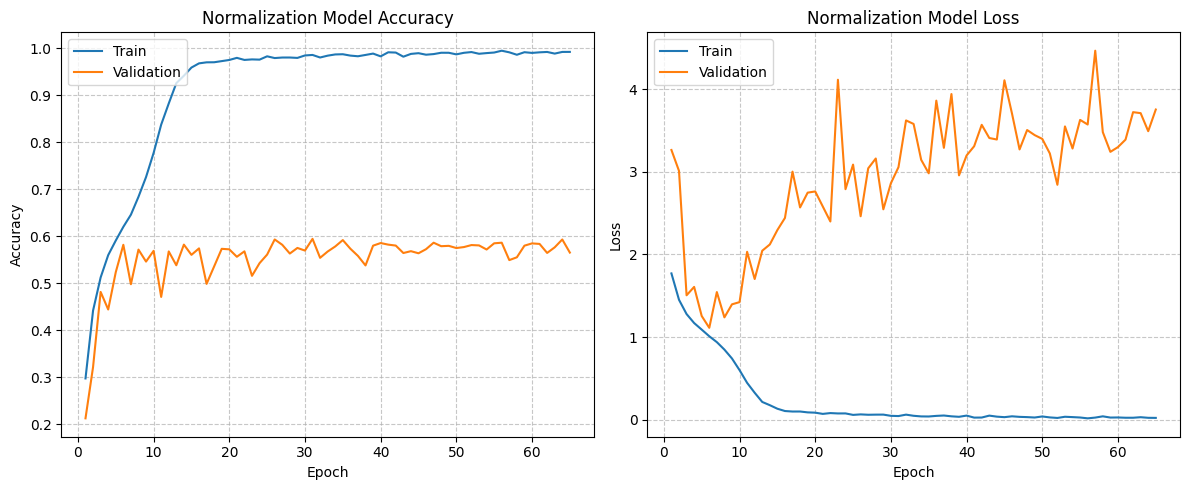

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The performance metrics comparison bar plot is being removed as per user request.
# Keeping the plotting of training and validation metrics for each method.
for method_name, history in histories.items():
    plot_training_history(history, method_name)

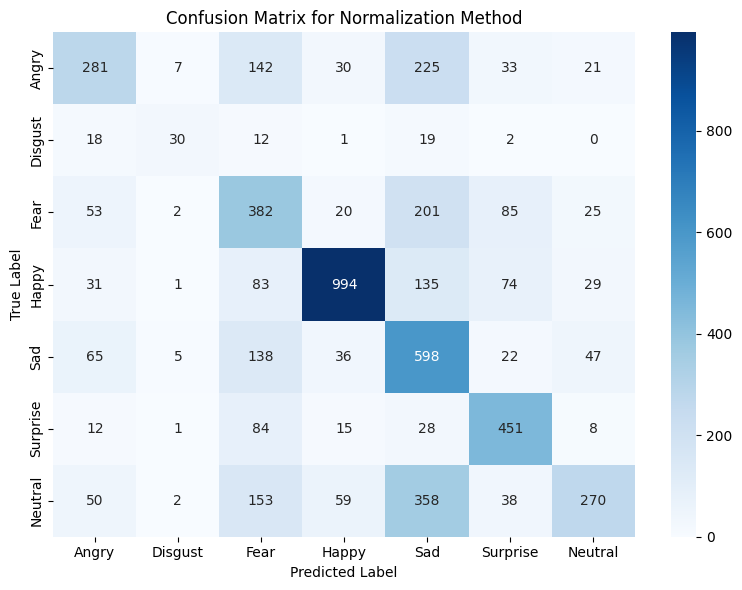

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class names for the FER2013 dataset
class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Plotting confusion matrices for each method
for method_name, cm in confusion_matrices.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for {method_name} Method')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()